### Import Libraries and Locate Project

In [1]:
from pathlib import Path
import sys
import json
import csv
import math
import time

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Find the project folder automatically
project_dir = None

for candidate in [Path.cwd(), *Path.cwd().parents]:
    possible_project = (
        candidate
        / "task1_llm"
        / "Samruddhi"
        / "src"
    )

    if possible_project.exists():
        project_dir = candidate
        break

if project_dir is None:
    raise FileNotFoundError(
        "Could not find the project directory."
    )

task_dir = project_dir / "task1_llm"
student_dir = task_dir / "Samruddhi"
src_dir = student_dir / "src"

sys.path.insert(0, str(src_dir))

print(f"Project directory: {project_dir}")
print(f"Source directory: {src_dir}")

Project directory: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1
Source directory: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\src


### Importing Project modules

In [2]:
from model import CharacterGPT, GPTConfig
from dataset import CharacterSequenceDataset

print("Project modules imported successfully.")

Project modules imported successfully.


### Selecting the Device

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        f"GPU memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

Using device: cuda
GPU: NVIDIA GeForce RTX 5090
GPU memory: 31.84 GB


### Load Vocabulary and Tokenized Data

In [4]:
processed_dir = student_dir / "data_processed"

vocab_file = processed_dir / "vocabulary.json"
train_tokens_file = processed_dir / "train_tokens.pt"
val_tokens_file = processed_dir / "val_tokens.pt"

with open(vocab_file, "r", encoding="utf-8") as file:
    vocabulary_data = json.load(file)

char_to_id = vocabulary_data["char_to_id"]
id_to_char = vocabulary_data["id_to_char"]

train_tokens = torch.load(
    train_tokens_file,
    map_location="cpu",
    weights_only=True
)

val_tokens = torch.load(
    val_tokens_file,
    map_location="cpu",
    weights_only=True
)

print(f"Vocabulary size: {len(char_to_id):,}")
print(f"Training tokens: {len(train_tokens):,}")
print(f"Validation tokens: {len(val_tokens):,}")

Vocabulary size: 108
Training tokens: 87,906,298
Validation tokens: 9,015,920


### Create the DataLoaders

In [5]:
block_size = 512
batch_size = 32

train_dataset = CharacterSequenceDataset(
    token_tensor=train_tokens,
    block_size=block_size,
    random_sampling=True
)

val_dataset = CharacterSequenceDataset(
    token_tensor=val_tokens,
    block_size=block_size,
    random_sampling=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

print(f"Training batches per epoch: {len(train_loader):,}")
print(f"Validation batches: {len(val_loader):,}")

Training batches per epoch: 5,365
Validation batches: 550


### Recreate the GPT Model

In [6]:
config = GPTConfig(
    vocab_size=len(char_to_id),
    block_size=512,
    n_embd=384,
    n_head=6,
    n_layer=6,
    dropout=0.1
)

experiment_model = CharacterGPT(config).to(device)

print("GPT model recreated.")
print(f"Vocabulary size: {config.vocab_size}")
print(f"Context length: {config.block_size}")
print(f"Embedding size: {config.n_embd}")
print(f"Attention heads: {config.n_head}")
print(f"Transformer blocks: {config.n_layer}")

GPT model recreated.
Vocabulary size: 108
Context length: 512
Embedding size: 384
Attention heads: 6
Transformer blocks: 6


### Load the Existing Best Checkpoint

In [8]:
checkpoint_dir = student_dir / "checkpoints"
best_model_file = checkpoint_dir / "model_after_21_epochs.pt"

checkpoint = torch.load(
    best_model_file,
    map_location=device,
    weights_only=False
)

# Support both checkpoint formats:
# 1. A plain model state dictionary
# 2. A dictionary containing model_state_dict
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    experiment_model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    experiment_model.load_state_dict(checkpoint)

print("Existing best model loaded successfully.")
print(f"Checkpoint: {best_model_file}")

Existing best model loaded successfully.
Checkpoint: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\checkpoints\model_after_21_epochs.pt


This loads already-trained model. We are not starting from random weights.

### Training again

In [13]:
experiment_epochs = 11
learning_rate = 3e-4
weight_decay = 0.01
gradient_clip = 1.0

warmup_epochs = 2
eval_iters = 50

steps_per_epoch = len(train_loader)

total_steps = (
    experiment_epochs * steps_per_epoch
)

warmup_steps = (
    warmup_epochs * steps_per_epoch
)

experiment_optimizer = torch.optim.AdamW(
    experiment_model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)


def learning_rate_schedule(current_step):
    # Linear warm-up
    if current_step < warmup_steps:
        return float(current_step + 1) / float(
            warmup_steps
        )

    # Cosine decay
    progress = (
        current_step - warmup_steps
    ) / float(
        max(1, total_steps - warmup_steps)
    )

    return 0.5 * (
        1.0 + math.cos(math.pi * progress)
    )


experiment_scheduler = torch.optim.lr_scheduler.LambdaLR(
    experiment_optimizer,
    lr_lambda=learning_rate_schedule
)

print("Experiment configuration created.")
print(f"Additional epochs: {experiment_epochs}")
print(f"Warm-up epochs: {warmup_epochs}")
print(f"Total steps: {total_steps:,}")

Experiment configuration created.
Additional epochs: 11
Warm-up epochs: 2
Total steps: 59,015


### Create the Evaluation Function

In [14]:
@torch.no_grad()
def estimate_experiment_loss(model, data_loader):
    model.eval()

    losses = []
    data_iterator = iter(data_loader)

    number_of_batches = min(
        eval_iters,
        len(data_loader)
    )

    for _ in range(number_of_batches):
        input_batch, target_batch = next(
            data_iterator
        )

        input_batch = input_batch.to(
            device,
            non_blocking=True
        )

        target_batch = target_batch.to(
            device,
            non_blocking=True
        )

        use_mixed_precision = (
            device.type == "cuda"
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_mixed_precision
        ):
            _, loss = model(
                input_batch,
                target_batch
            )

        losses.append(loss.item())

    model.train()

    return sum(losses) / len(losses)

### Prepare Experiment Tracking

In [15]:
experiment_output_dir = (
    student_dir
    / "outputs"
    / "learning_rate_experiment"
)

experiment_checkpoint_dir = (
    student_dir
    / "checkpoints"
    / "learning_rate_experiment"
)

experiment_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

experiment_checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

experiment_train_losses = []
experiment_val_losses = []
experiment_learning_rates = []
experiment_gradient_norms = []

tokens_processed = 0

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

training_start_time = time.time()

print("Experiment tracking prepared.")

Experiment tracking prepared.


### Train for 11 Additional Epochs

In [17]:
from tqdm.auto import tqdm

experiment_model.train()

best_experiment_val_loss = float("inf")
best_experiment_epoch = 0

for epoch in range(experiment_epochs):

    epoch_start_time = time.time()
    epoch_loss_total = 0.0
    epoch_gradient_norms = []

    train_loader_iterator = iter(train_loader)

    progress_bar = tqdm(
        range(steps_per_epoch),
        desc=f"Epoch {epoch + 1}/{experiment_epochs}"
    )

    for step in progress_bar:

        input_batch, target_batch = next(
            train_loader_iterator
        )

        input_batch = input_batch.to(
            device,
            non_blocking=True
        )

        target_batch = target_batch.to(
            device,
            non_blocking=True
        )

        tokens_processed += input_batch.numel()

        experiment_optimizer.zero_grad(
            set_to_none=True
        )

        use_mixed_precision = (
            device.type == "cuda"
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=use_mixed_precision
        ):
            _, loss = experiment_model(
                input_batch,
                target_batch
            )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                experiment_model.parameters(),
                gradient_clip
            )
        )

        experiment_optimizer.step()

        # Update the learning rate
        experiment_scheduler.step()

        epoch_loss_total += loss.item()
        epoch_gradient_norms.append(
            gradient_norm.item()
        )

        current_learning_rate = (
            experiment_optimizer.param_groups[0]["lr"]
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{current_learning_rate:.2e}"
        )

    average_train_loss = (
        epoch_loss_total / steps_per_epoch
    )

    average_gradient_norm = (
        sum(epoch_gradient_norms)
        / len(epoch_gradient_norms)
    )

    validation_loss = estimate_experiment_loss(
        experiment_model,
        val_loader
    )

    experiment_train_losses.append(
        average_train_loss
    )

    experiment_val_losses.append(
        validation_loss
    )

    experiment_learning_rates.append(
        current_learning_rate
    )

    experiment_gradient_norms.append(
        average_gradient_norm
    )

    epoch_time = (
        time.time() - epoch_start_time
    )

    print(
        f"Epoch {epoch + 1:>2}/{experiment_epochs} | "
        f"Train loss: {average_train_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Learning rate: {current_learning_rate:.8f} | "
        f"Gradient norm: {average_gradient_norm:.4f} | "
        f"Time: {epoch_time:.2f} sec"
    )

    if validation_loss < best_experiment_val_loss:

        best_experiment_val_loss = validation_loss
        best_experiment_epoch = epoch + 1

        best_experiment_file = (
            experiment_checkpoint_dir
            / "best_model_with_scheduler.pt"
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": (
                    experiment_model.state_dict()
                ),
                "optimizer_state_dict": (
                    experiment_optimizer.state_dict()
                ),
                "scheduler_state_dict": (
                    experiment_scheduler.state_dict()
                ),
                "validation_loss": validation_loss,
                "config": config.__dict__
            },
            best_experiment_file
        )

print("\nExperiment training completed.")
print(
    f"Best validation loss: "
    f"{best_experiment_val_loss:.4f}"
)
print(
    f"Best epoch: {best_experiment_epoch}"
)

C:\Users\samruddhi\anaconda3\envs\data266_lab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch 1/11: 100%|██████████| 5365/5365 [03:41<00:00, 24.17it/s, loss=0.4908, lr=1.89e-04]


Epoch  1/11 | Train loss: 0.4955 | Validation loss: 0.5444 | Learning rate: 0.00018917 | Gradient norm: 0.1537 | Time: 222.59 sec


Epoch 2/11: 100%|██████████| 5365/5365 [03:42<00:00, 24.10it/s, loss=0.5346, lr=2.99e-04]


Epoch  2/11 | Train loss: 0.5037 | Validation loss: 0.5489 | Learning rate: 0.00029938 | Gradient norm: 0.1571 | Time: 223.26 sec


Epoch 3/11: 100%|██████████| 5365/5365 [03:42<00:00, 24.15it/s, loss=0.5182, lr=2.86e-04]


...

Epoch  9/11 | Train loss: 0.4804 | Validation loss: 0.5294 | Learning rate: 0.00002680 | Gradient norm: 0.1568 | Time: 222.05 sec


Epoch 10/11: 100%|██████████| 5365/5365 [03:39<00:00, 24.42it/s, loss=0.4981, lr=4.96e-06]


Epoch 10/11 | Train loss: 0.4778 | Validation loss: 0.5280 | Learning rate: 0.00000496 | Gradient norm: 0.1573 | Time: 220.37 sec


Epoch 11/11: 100%|██████████| 5365/5365 [03:39<00:00, 24.49it/s, loss=0.4697, lr=6.22e-07]


Epoch 11/11 | Train loss: 0.4773 | Validation loss: 0.5281 | Learning rate: 0.00000062 | Gradient norm: 0.1575 | Time: 219.69 sec

Experiment training completed.
Best validation loss: 0.5280
Best epoch: 10


### Calculate Training Performance

In [18]:
total_training_time = (
    time.time() - training_start_time
)

training_tokens_per_second = (
    tokens_processed / total_training_time
)

if device.type == "cuda":
    peak_training_memory_gb = (
        torch.cuda.max_memory_allocated(device)
        / 1024**3
    )
else:
    peak_training_memory_gb = 0.0

print("Training performance:")
print(
    f"Total training time: "
    f"{total_training_time / 60:.2f} minutes"
)
print(
    f"Tokens processed: "
    f"{tokens_processed:,}"
)
print(
    f"Training speed: "
    f"{training_tokens_per_second:,.2f} tokens/second"
)
print(
    f"Peak GPU memory: "
    f"{peak_training_memory_gb:.3f} GB"
)

Training performance:
Total training time: 42.52 minutes
Tokens processed: 989,839,360
Training speed: 387,965.63 tokens/second
Peak GPU memory: 3.911 GB


### Plot Experiment Loss Curves

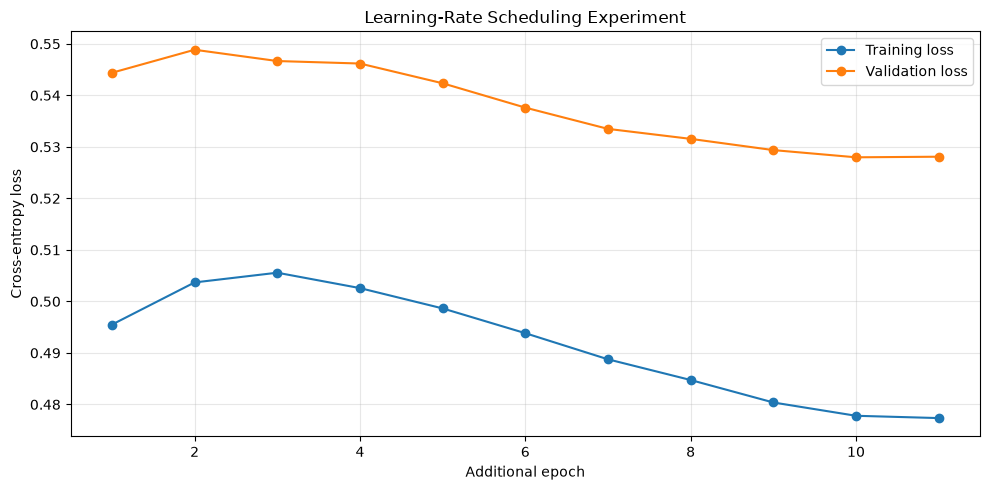

Saved plot to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\outputs\learning_rate_experiment\scheduler_loss_curves.png


In [19]:
plt.figure(figsize=(10, 5))

epochs = range(
    1,
    experiment_epochs + 1
)

plt.plot(
    epochs,
    experiment_train_losses,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    experiment_val_losses,
    marker="o",
    label="Validation loss"
)

plt.xlabel("Additional epoch")
plt.ylabel("Cross-entropy loss")
plt.title(
    "Learning-Rate Scheduling Experiment"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

loss_plot_file = (
    experiment_output_dir
    / "scheduler_loss_curves.png"
)

plt.savefig(
    loss_plot_file,
    dpi=150
)

plt.show()

print(f"Saved plot to: {loss_plot_file}")

### Plot the Learning Rate

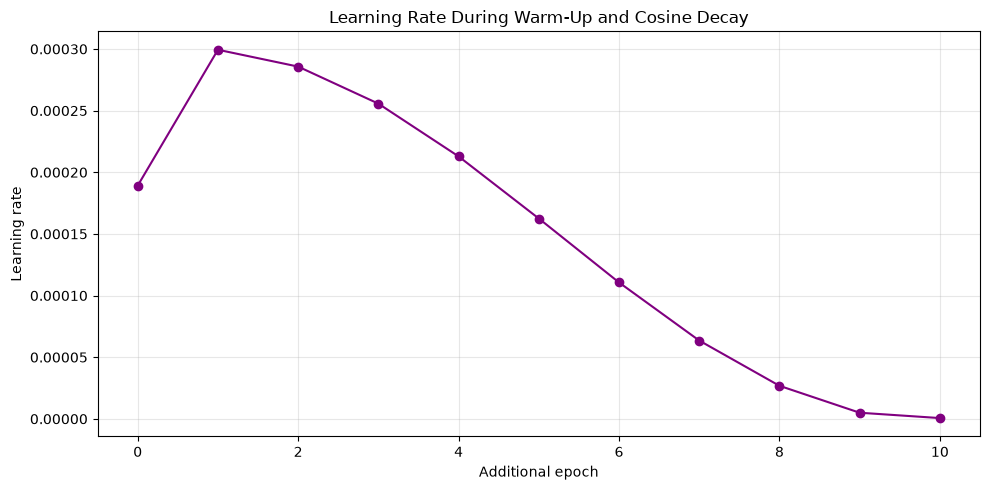

Saved plot to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\outputs\learning_rate_experiment\learning_rate_schedule.png


In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    experiment_learning_rates,
    marker="o",
    color="purple"
)

plt.xlabel("Additional epoch")
plt.ylabel("Learning rate")
plt.title(
    "Learning Rate During Warm-Up and Cosine Decay"
)

plt.grid(alpha=0.3)
plt.tight_layout()

learning_rate_plot_file = (
    experiment_output_dir
    / "learning_rate_schedule.png"
)

plt.savefig(
    learning_rate_plot_file,
    dpi=150
)

plt.show()

print(
    f"Saved plot to: "
    f"{learning_rate_plot_file}"
)

### Save Experiment Results

In [21]:
experiment_metrics_file = (
    experiment_output_dir
    / "learning_rate_experiment_metrics.csv"
)

experiment_metrics = [
    ["metric", "value"],
    [
        "additional_epochs",
        experiment_epochs
    ],
    [
        "warmup_epochs",
        warmup_epochs
    ],
    [
        "best_validation_loss",
        best_experiment_val_loss
    ],
    [
        "best_epoch",
        best_experiment_epoch
    ],
    [
        "final_training_loss",
        experiment_train_losses[-1]
    ],
    [
        "final_validation_loss",
        experiment_val_losses[-1]
    ],
    [
        "total_training_time_seconds",
        total_training_time
    ],
    [
        "training_tokens_per_second",
        training_tokens_per_second
    ],
    [
        "peak_training_memory_gb",
        peak_training_memory_gb
    ],
    [
        "initial_learning_rate",
        learning_rate
    ],
    [
        "weight_decay",
        weight_decay
    ]
]

with open(
    experiment_metrics_file,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)
    writer.writerows(experiment_metrics)

print(
    f"Saved experiment metrics to: "
    f"{experiment_metrics_file}"
)

Saved experiment metrics to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\outputs\learning_rate_experiment\learning_rate_experiment_metrics.csv


### Compare Original and Experimental Results

In [23]:
print("MODEL COMPARISON")
print("=" * 60)

print(
    "Original model:",
    "trained for 21 epochs with fixed learning rate"
)

print(
    f"Original validation loss: "
    f"{0.5496:.4f}"
)

print(
    "Experimental model:",
    "11 additional epochs with warm-up and cosine decay"
)

print(
    f"Experimental best validation loss: "
    f"{best_experiment_val_loss:.4f}"
)

if best_experiment_val_loss < 0.5496:
    print(
        "\nResult: The scheduled experiment improved "
        "the validation loss."
    )
else:
    print(
        "\nResult: The scheduled experiment did not "
        "improve the validation loss."
    )

MODEL COMPARISON
Original model: trained for 21 epochs with fixed learning rate
Original validation loss: 0.5496
Experimental model: 11 additional epochs with warm-up and cosine decay
Experimental best validation loss: 0.5280

Result: The scheduled experiment improved the validation loss.


### Generate Text from the Improved Model

In [24]:
# Load the best scheduled-training checkpoint
best_experiment_file = (
    experiment_checkpoint_dir
    / "best_model_with_scheduler.pt"
)

best_experiment_checkpoint = torch.load(
    best_experiment_file,
    map_location=device,
    weights_only=False
)

experiment_model.load_state_dict(
    best_experiment_checkpoint["model_state_dict"]
)

experiment_model.eval()

print("Best experimental model loaded.")
print(
    f"Best validation loss: "
    f"{best_experiment_checkpoint['validation_loss']:.4f}"
)

Best experimental model loaded.
Best validation loss: 0.5280


### Generate a Story

In [25]:
prompt = "Once upon a time"

unknown_token_id = char_to_id.get(
    "<UNK>",
    0
)

prompt_ids = [
    char_to_id.get(
        character,
        unknown_token_id
    )
    for character in prompt
]

prompt_tensor = torch.tensor(
    [prompt_ids],
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    generated_ids = experiment_model.generate(
        prompt_tensor,
        max_new_tokens=300,
        temperature=0.8
    )

generated_text = "".join(
    id_to_char[str(int(token_id))]
    for token_id in generated_ids[0]
)

print(generated_text)

Once upon a time, there was a kind little girl who liked to collect beans. She had a special beans that she picked up to pick up the beans and made them shiny and sticky. One day, the little girl decided to collect some beans for her treat. She grabbed her special beans and moved to the yard. The beans showed her h


In [26]:
experiment_generated_file = (
    experiment_output_dir
    / "generated_sample_scheduler.txt"
)

with open(
    experiment_generated_file,
    "w",
    encoding="utf-8"
) as file:
    file.write(generated_text)

print(
    f"Generated text saved to: "
    f"{experiment_generated_file}"
)

Generated text saved to: C:\Users\samruddhi\Desktop\Sam\Gen_AI_Lab1\task1_llm\Samruddhi\outputs\learning_rate_experiment\generated_sample_scheduler.txt
